# TP4

##  Chargement et prétraitement du corpus

In [14]:
from sklearn.datasets import fetch_20newsgroups

newsgroups = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
raw_texts = newsgroups.data[:1000]  


### Prétraitement des textes

In [15]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # liens
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and t.isalpha()]
    return tokens

cleaned_corpus = [clean_text(doc) for doc in raw_texts]


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yann/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Entraîner Word2Vec

In [16]:
from gensim.models import Word2Vec

model = Word2Vec(sentences=cleaned_corpus, vector_size=100, window=5, min_count=5, workers=4)


In [4]:
# model.save("word2vec_newsgroups.model")


In [17]:
print(model.wv.most_similar("computer"))


[('would', 0.9997797012329102), ('way', 0.9997761249542236), ('number', 0.9997705221176147), ('one', 0.9997690916061401), ('work', 0.9997689723968506), ('get', 0.9997612833976746), ('system', 0.9997557401657104), ('many', 0.9997556209564209), ('armenians', 0.9997516870498657), ('well', 0.9997513890266418)]


In [18]:
print(model.wv.similarity("science", "technology"))


0.9993243


### Visualizatio

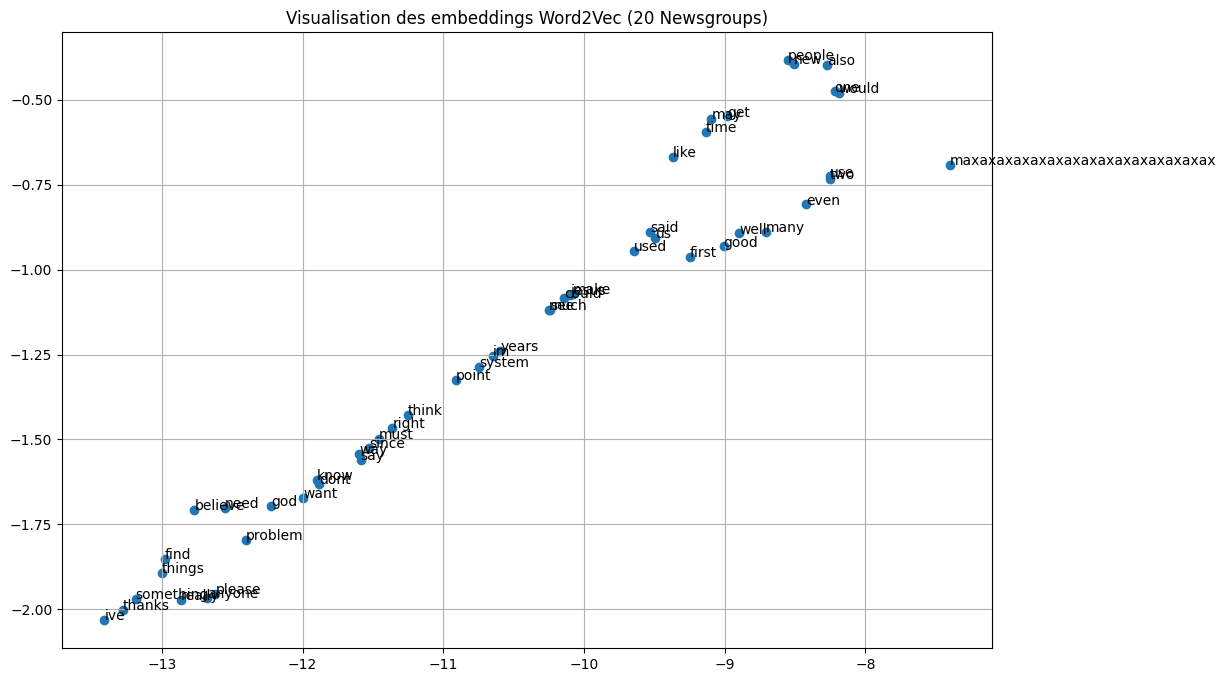

In [19]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Choisir 50 mots fréquents
words = model.wv.index_to_key[:50]
vectors = np.array([model.wv[word] for word in words])

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vectors_2d = tsne.fit_transform(vectors)

# Affichage
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))
plt.title("Visualisation des embeddings Word2Vec (20 Newsgroups)")
plt.grid(True)
plt.show()


# With more words tout le corpus

In [33]:
raw_texts = newsgroups.data 


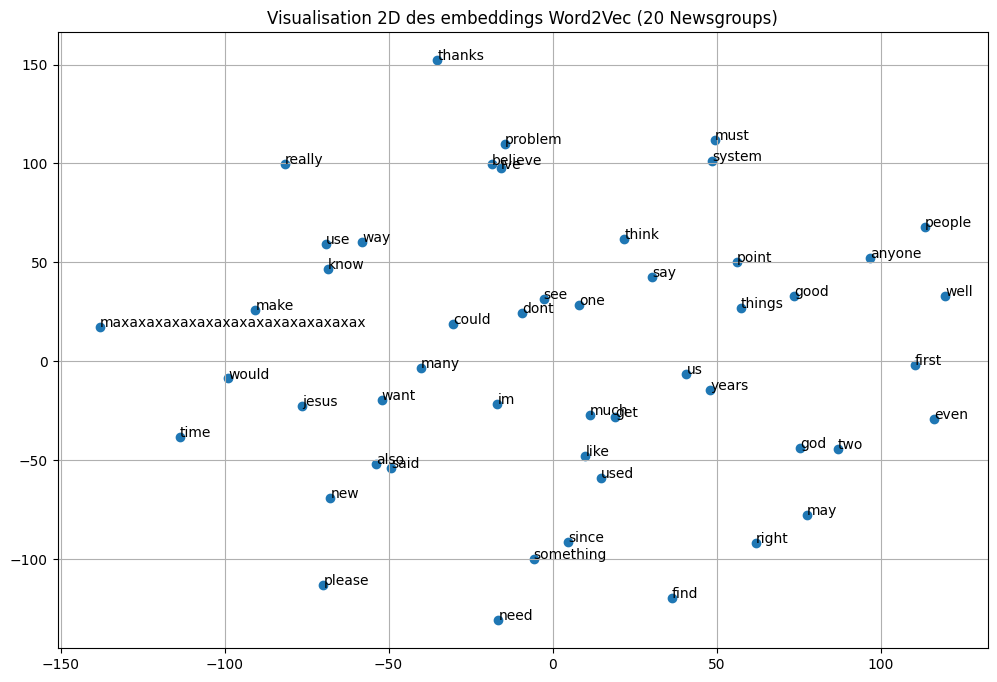

In [31]:

words = model.wv.index_to_key[:50]
vectors = np.array([model.wv[word] for word in words])

# 7. Réduction de dimension avec t-SNE
tsne = TSNE(n_components=3, random_state=42, perplexity=30)
vectors_2d = tsne.fit_transform(vectors)

# 8. Affichage matplotlib
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.title("Visualisation 2D des embeddings Word2Vec (20 Newsgroups)")
plt.grid(True)
plt.show()

In [34]:
from gensim.models import Word2Vec
cleaned_corpus = [clean_text(doc) for doc in raw_texts]
model = Word2Vec(sentences=cleaned_corpus, vector_size=100, window=5, min_count=5, workers=4)


In [35]:
print(model.wv.most_similar("computer"))


[('network', 0.9471612572669983), ('digital', 0.9091249108314514), ('products', 0.9007555842399597), ('systems', 0.8915103077888489), ('spect', 0.8872766494750977), ('voice', 0.8858819007873535), ('ibm', 0.8848412036895752), ('software', 0.8827233910560608), ('dsp', 0.8814640641212463), ('gfxbase', 0.8813415765762329)]


In [36]:
print(model.wv.similarity("science", "technology"))


0.6963022
